# Should We Roll Out the New Recommender? And How Many Push Notifications Are Too Many?
### A tech-industry project built on *Causal Inference in Python*, Chapter 7 — "Metalearners"

**Business context.** You're on the growth/ML platform team at a streaming
app (think Spotify/Netflix-style product). Two live decisions on your desk:

1. **Binary treatment — algorithm rollout.** Engineering shipped a new
   recommendation algorithm. It was already canary-released to an opt-in
   beta cohort (so the rollout data is **confounded**: engaged power-users
   disproportionately opted in). You also have a small **randomized A/B
   test** slice where the algorithm was assigned by coin flip. Question:
   *for which users does the new algorithm actually increase watch time,
   and should we roll it out to everyone, or only to the users who benefit?*
   This is a **discrete-treatment CATE** problem — T-Learner / X-Learner
   territory.

2. **Continuous treatment — notification frequency.** The lifecycle
   marketing team can send between 0 and 14 push notifications per week per
   user. More notifications sometimes drive more app opens — but too many
   causes fatigue, unsubscribes, and diminishing (or negative) returns.
   Historically, notification frequency was **not randomized**: the team
   already targets lapsed users with more nudges and engaged users with
   fewer (a "win-back" targeting policy) — another confounded rollout.
   Question: *what is each user's engagement dose-response curve, and what
   is the engagement-maximizing notification frequency per user, under a
   fatigue budget?* This is a **continuous-treatment CATE** problem —
   S-Learner / R-Learner (Double-ML) territory.

**What this notebook does**, directly mirroring the chapter's structure and
techniques:

- Part 1 — simulate confounded "beta rollout" data + a randomized holdout,
  exactly like the book's `email_obs` / `email_rnd` split, but for an
  algorithm rollout.
- Part 2 — implement **T-Learner** and **X-Learner** from scratch, evaluate
  with the **cumulative gain curve**, and reproduce the book's
  **regularization-bias experiment** using a realistic **canary release**
  (only ~3% of users see the new algorithm at first) to show *why* the
  X-Learner matters for staged rollouts specifically.
- Part 3 — simulate confounded notification-frequency data (continuous
  treatment) + a randomized holdout.
- Part 4 — implement the **S-Learner** (counterfactual dose-response curves
  + slope extraction) and the **R-Learner / Double-ML** (direct CATE via
  orthogonalized residuals) for the continuous case.
- Part 5 — turn both into **operating decisions**: a staged full rollout
  plan under an infra-capacity constraint, and a per-user notification
  frequency policy under a fatigue budget — plus a decision-guide summary.

> As before, we **simulate data with the same causal structure** the
> real problem would have (confounding + heterogeneous effects + a
> randomized holdout for honest evaluation), which lets us also check every
> learner against the ground-truth CATE.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
import statsmodels.api as sm
import statsmodels.formula.api as smf
from toolz import curry

np.random.seed(123)
pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


# Part 1 — Data: the recommender-algorithm rollout

`data_beta` is a **large, confounded** dataset (300,000 users): whether a
user has the new algorithm depends on whether they **opted into the beta**,
and opt-in was correlated with engagement (power users, long tenure,
frequent recent logins opted in more). `data_ab` is a **small, randomized**
A/B test (10,000 users) — the algorithm was assigned by coin flip — used
**only for evaluation**.

**Covariates:** `tenure_months`, `past_watch_hours` (avg weekly hours before
the rollout), `days_since_last_login` (recency, lower = more engaged),
`catalog_breadth` (how many distinct genres a user has watched — a proxy
for how "explorable" their taste is), `num_devices`.

**True effect design:** the new algorithm helps most for users with **low
catalog breadth** (their old recommendations were stuck in a rut — fresh
recommendations have more room to help) and users with **more tenure**
(more watch history for the algorithm to learn from). This means, unlike
the discount example, the biggest winners from the treatment are *not*
simply "the most engaged" users — a more realistic and slightly trickier
targeting problem.


In [2]:
def simulate_users(n, seed):
    rng = np.random.default_rng(seed)
    tenure_months = rng.exponential(18, n).clip(0, 96)
    past_watch_hours = rng.gamma(4, 2, n).clip(0, 40)          # avg weekly hours
    days_since_last_login = rng.exponential(6, n).clip(0, 60)  # recency
    catalog_breadth = rng.integers(1, 15, n)                   # distinct genres watched
    num_devices = rng.integers(1, 5, n)

    return pd.DataFrame(dict(
        tenure_months=tenure_months,
        past_watch_hours=past_watch_hours,
        days_since_last_login=days_since_last_login,
        catalog_breadth=catalog_breadth,
        num_devices=num_devices,
    ))


def assign_beta_optin(X, rng):
    # Power users (long tenure, high past watch, recently active, many devices)
    # were more likely to opt into the beta -> confounding.
    logit = (
        -1.5
        + 0.02 * X["tenure_months"]
        + 0.06 * X["past_watch_hours"]
        - 0.04 * X["days_since_last_login"]
        + 0.15 * X["num_devices"]
    )
    p = (1 / (1 + np.exp(-logit))).clip(0.02, 0.97)
    T = rng.binomial(1, p)
    return T, p


def true_cate_algo(X):
    # Biggest winners: low catalog breadth (stuck-in-a-rut users) + high tenure
    # (more watch history for the algorithm to exploit).
    effect = (
        1.5
        + 0.25 * (15 - X["catalog_breadth"])
        + 0.03 * X["tenure_months"]
    )
    return effect.clip(lower=0)


def simulate_watch_hours(X, T, rng):
    tau = true_cate_algo(X)
    baseline = (
        3.0
        + 0.55 * X["past_watch_hours"]
        + 0.10 * X["catalog_breadth"]
        - 0.05 * X["days_since_last_login"]
        + 0.30 * X["num_devices"]
    )
    noise = rng.normal(0, 2.5, len(X))
    Y = (baseline + T * tau + noise).clip(lower=0)
    return Y, tau


rng = np.random.default_rng(123)

# --- Large, confounded beta-rollout data ---
X_beta = simulate_users(300_000, seed=11)
T_beta, ps_true = assign_beta_optin(X_beta, rng)
Y_beta, tau_beta = simulate_watch_hours(X_beta, T_beta, rng)
data_beta = X_beta.assign(new_algo=T_beta, weekly_watch_hours=Y_beta)

# --- Small randomized A/B test, evaluation only ---
X_ab = simulate_users(10_000, seed=22)
T_ab = rng.binomial(1, 0.5, len(X_ab))
Y_ab, tau_ab_true = simulate_watch_hours(X_ab, T_ab, rng)
data_ab = X_ab.assign(new_algo=T_ab, weekly_watch_hours=Y_ab, true_cate=tau_ab_true)

print(len(data_beta), len(data_ab))
data_ab.head()


300000 10000


,tenure_months,past_watch_hours,days_since_last_login,catalog_breadth,num_devices,new_algo,weekly_watch_hours,true_cate
0,5.052313,6.606454,0.682604,3,2,1,15.548857,4.651569
1,5.639654,9.400845,0.017124,6,2,0,11.676683,3.919190
2,1.325745,11.318358,0.976405,10,4,1,12.744168,2.789772
3,10.917061,14.340256,0.001830,6,3,1,12.092196,4.077512
4,27.715792,10.096779,3.955787,2,3,0,10.916664,5.581474


In [3]:
naive_beta = data_beta.groupby("new_algo")["weekly_watch_hours"].mean()
naive_ab = data_ab.groupby("new_algo")["weekly_watch_hours"].mean()

print("Naive diff-in-means, BETA (confounded) data:", naive_beta[1] - naive_beta[0])
print("Naive diff-in-means, RANDOMIZED A/B data (unbiased ATE estimate):", naive_ab[1] - naive_ab[0])
print("True ATE (simulation ground truth):", true_cate_algo(pd.concat([X_beta, X_ab])).mean())


Naive diff-in-means, BETA (confounded) data: 4.645490407646745
Naive diff-in-means, RANDOMIZED A/B data (unbiased ATE estimate): 3.8766314783312854
True ATE (simulation ground truth): 3.914245898921789


As expected, the confounded beta comparison **overstates** the algorithm's
effect, because the same traits that led users to opt into the beta also
predict higher baseline watch time. Everything below trains **only** on
`data_beta` and evaluates **only** on the randomized `data_ab`.


In [4]:
y = "weekly_watch_hours"
T = "new_algo"
X = ["tenure_months", "past_watch_hours", "days_since_last_login", "catalog_breadth", "num_devices"]

train, test = data_beta, data_ab
print("Covariates:", X)


Covariates: ['tenure_months', 'past_watch_hours', 'days_since_last_login', 'catalog_breadth', 'num_devices']


## 2. Evaluation tooling (same cumulative gain machinery as the book, Chapter 6/7)


In [5]:
def cumulative_gain_curve(df, prediction, y, t, steps=100):
    size = len(df)
    ordered = df.sort_values(prediction, ascending=False).reset_index(drop=True)
    n_rows = list(range(1, size, max(1, size // steps))) + [size]

    gains = []
    for rows in n_rows:
        subset = ordered.head(rows)
        treated = subset.query(f"{t}==1")
        control = subset.query(f"{t}==0")
        if len(treated) == 0 or len(control) == 0:
            gains.append(0)
            continue
        effect = treated[y].mean() - control[y].mean()
        gains.append(effect * rows / size)

    return np.array(n_rows) / size * 100, np.array(gains)


def auc_relative_to_baseline(x_pct, gains):
    baseline = np.linspace(0, gains[-1], len(gains))
    trapz_fn = getattr(np, "trapezoid", None) or np.trapz
    return trapz_fn(gains - baseline, x_pct)


def plot_cumulative_gain(df, prediction, y, t, title, ax=None):
    x_pct, gains = cumulative_gain_curve(df, prediction, y, t)
    auc = auc_relative_to_baseline(x_pct, gains)
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(x_pct, gains, label=f"AUC: {auc:.2f}")
    ax.plot([0, 100], [0, gains[-1]], "--", color="gray", label="Baseline")
    ax.set_title(title)
    ax.set_xlabel("% of users targeted (sorted by predicted CATE)")
    ax.set_ylabel("Cumulative gain (watch hours)")
    ax.legend()
    return auc


def pehe(true_effect, pred_effect):
    return float(np.sqrt(np.mean((np.asarray(true_effect) - np.asarray(pred_effect)) ** 2)))


## 3. T-Learner — should engineering roll the algorithm out to everyone?

$$\hat\mu_0(x) \approx E[Y \mid T{=}0, X], \qquad \hat\mu_1(x) \approx E[Y \mid T{=}1, X], \qquad \hat\tau(x) = \hat\mu_1(x) - \hat\mu_0(x)$$


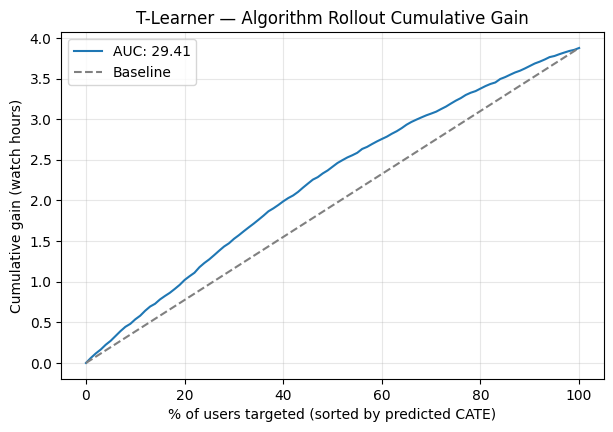

T-Learner PEHE: 0.2680335948567618


In [6]:
np.random.seed(123)
m0 = LGBMRegressor(verbosity=-1)
m1 = LGBMRegressor(verbosity=-1)

m0.fit(train.query(f"{T}==0")[X], train.query(f"{T}==0")[y])
m1.fit(train.query(f"{T}==1")[X], train.query(f"{T}==1")[y])

t_learner_pred = test.assign(cate=m1.predict(test[X]) - m0.predict(test[X]))

auc_t = plot_cumulative_gain(t_learner_pred, "cate", y, T, "T-Learner — Algorithm Rollout Cumulative Gain")
plt.show()
print("T-Learner PEHE:", pehe(test["true_cate"], t_learner_pred["cate"]))


## 4. X-Learner — correcting for the canary/beta imbalance

Beta opt-in wasn't 50/50 — it skewed toward power users, and in a real
staged rollout the **early canary population is often a small minority** of
all users. The X-Learner's propensity-weighted second stage is built for
exactly this situation.


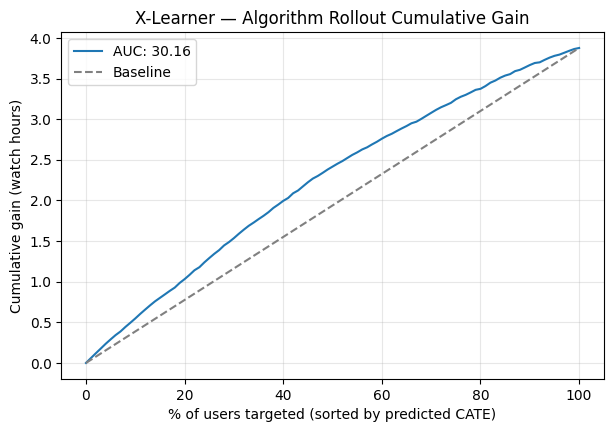

X-Learner PEHE: 0.13439867570458108


In [7]:
np.random.seed(123)

ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(train[X], train[T])

train_t0 = train.query(f"{T}==0")
train_t1 = train.query(f"{T}==1")

m0 = LGBMRegressor(verbosity=-1)
m1 = LGBMRegressor(verbosity=-1)
m0.fit(train_t0[X], train_t0[y])
m1.fit(train_t1[X], train_t1[y])

tau_hat_0 = m1.predict(train_t0[X]) - train_t0[y]
tau_hat_1 = train_t1[y] - m0.predict(train_t1[X])

m_tau_0 = LGBMRegressor(verbosity=-1)
m_tau_1 = LGBMRegressor(verbosity=-1)
m_tau_0.fit(train_t0[X], tau_hat_0)
m_tau_1.fit(train_t1[X], tau_hat_1)

ps_test = ps_model.predict_proba(test[X])[:, 1]
x_learner_pred = test.assign(
    cate=ps_test * m_tau_0.predict(test[X]) + (1 - ps_test) * m_tau_1.predict(test[X])
)

auc_x = plot_cumulative_gain(x_learner_pred, "cate", y, T, "X-Learner — Algorithm Rollout Cumulative Gain")
plt.show()
print("X-Learner PEHE:", pehe(test["true_cate"], x_learner_pred["cate"]))


In [8]:
pd.DataFrame({
    "T-Learner": dict(AUC=auc_t, PEHE=pehe(test["true_cate"], t_learner_pred["cate"])),
    "X-Learner": dict(AUC=auc_x, PEHE=pehe(test["true_cate"], x_learner_pred["cate"])),
}).T


,AUC,PEHE
T-Learner,29.408797,0.268034
X-Learner,30.162189,0.134399


## 5. Reproducing the book's regularization-bias experiment with a *realistic canary release*

Real rollouts rarely start at 50/50 — they start with a **small canary**
(often 1-5% of traffic) to limit blast radius. Let's simulate exactly that:
only 3% of users are on the new algorithm, the baseline watch-time surface
is nonlinear in `catalog_breadth`, and the true effect is **constant**
(every user gets the same absolute lift) — the precise setup the book uses
to show T-Learner regularization bias.


In [9]:
def simulate_canary(n=4000, canary_share=0.03, seed=1):
    rng = np.random.default_rng(seed)
    breadth = rng.uniform(-1, 1, n)          # standardized catalog-breadth score
    T = rng.binomial(1, canary_share, n)

    mu0 = 0.4 * np.exp(-30 * breadth ** 2)   # sharp nonlinearity (rut-users cluster near 0)
    tau_true = np.ones(n) * 1.0              # CONSTANT true lift
    noise = rng.normal(0, 0.05, n)

    Y = mu0 + T * tau_true + noise
    return pd.DataFrame(dict(breadth=breadth, T=T, Y=Y, tau_true=tau_true))


canary = simulate_canary()
canary_train, canary_test = canary.iloc[: len(canary)//2], canary.iloc[len(canary)//2:]
print("Users on the new algorithm (canary) in training set:", canary_train['T'].sum(), "/", len(canary_train))


Users on the new algorithm (canary) in training set: 60 / 2000


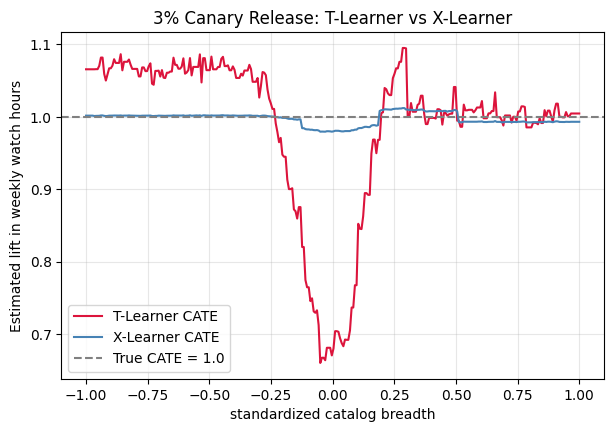

T-Learner PEHE (3% canary): 0.10870946838185029
X-Learner PEHE (3% canary): 0.008589909090666826


In [10]:
np.random.seed(123)
m0_c = LGBMRegressor(min_child_samples=25, verbosity=-1)
m1_c = LGBMRegressor(min_child_samples=25, verbosity=-1)
m0_c.fit(canary_train.query("T==0")[["breadth"]], canary_train.query("T==0")["Y"])
m1_c.fit(canary_train.query("T==1")[["breadth"]], canary_train.query("T==1")["Y"])

grid = pd.DataFrame({"breadth": np.linspace(-1, 1, 300)})
mu0_hat = m0_c.predict(grid)
mu1_hat = m1_c.predict(grid)
t_learner_cate_canary = mu1_hat - mu0_hat

ps_model_c = LogisticRegression(max_iter=1000)
ps_model_c.fit(canary_train[["breadth"]], canary_train["T"])

t0c = canary_train.query("T==0")
t1c = canary_train.query("T==1")
tau_hat_0_c = m1_c.predict(t0c[["breadth"]]) - t0c["Y"]
tau_hat_1_c = t1c["Y"] - m0_c.predict(t1c[["breadth"]])

m_tau0_c = LGBMRegressor(verbosity=-1)
m_tau1_c = LGBMRegressor(verbosity=-1)
m_tau0_c.fit(t0c[["breadth"]], tau_hat_0_c)
m_tau1_c.fit(t1c[["breadth"]], tau_hat_1_c)

ps_grid_c = ps_model_c.predict_proba(grid)[:, 1]
x_learner_cate_canary = ps_grid_c * m_tau0_c.predict(grid) + (1 - ps_grid_c) * m_tau1_c.predict(grid)

fig, ax = plt.subplots()
ax.plot(grid["breadth"], t_learner_cate_canary, color="crimson", label="T-Learner CATE")
ax.plot(grid["breadth"], x_learner_cate_canary, color="steelblue", label="X-Learner CATE")
ax.axhline(1.0, color="gray", linestyle="--", label="True CATE = 1.0")
ax.legend()
ax.set_title("3% Canary Release: T-Learner vs X-Learner")
ax.set_xlabel("standardized catalog breadth")
ax.set_ylabel("Estimated lift in weekly watch hours")
plt.show()

print("T-Learner PEHE (3% canary):", pehe(canary_test["tau_true"],
      np.interp(canary_test["breadth"], grid["breadth"], t_learner_cate_canary)))
print("X-Learner PEHE (3% canary):", pehe(canary_test["tau_true"],
      np.interp(canary_test["breadth"], grid["breadth"], x_learner_cate_canary)))


Exactly as the book warns: with only 3% of users on the new algorithm, the
T-Learner's $\hat\mu_1$ model is starved of data and gets over-regularized,
so the *difference* of the two outcome models incorrectly dips right where
the outcome surface is nonlinear — even though the true lift is flat. The
X-Learner, using the propensity score to down-weight the noisy treated-only
model, tracks the true constant effect far more closely. **This is exactly
the situation most real canary releases start in** — which is why teams
running staged rollouts should reach for the X-Learner rather than the
T-Learner during the early canary phase.


# Part 2 — Continuous treatment: how many push notifications per week?

Now the second decision. `notif_obs` is a **confounded, large observational**
dataset: the lifecycle marketing team already runs a **win-back policy** —
users who haven't opened the app recently get *more* notifications, while
already-engaged users get fewer. That means notification frequency is
correlated with (low) baseline engagement — a different, and trickier,
kind of confounding than the rollout case. `notif_rnd` is a **small
randomized** test (frequency assigned uniformly at random) used only for
evaluation.

**Outcome:** `weekly_app_opens`.
**Treatment:** `notifs_per_week` (continuous, 0–14).
**True effect design:** engagement lift from notifications is strongest for
**moderately active users** and **weakens (and can go negative — fatigue)**
for both very lapsed users (who ignore notifications) and very engaged
users (who don't need reminders and can be annoyed into disengaging).


In [11]:
def simulate_notif_users(n, seed):
    rng = np.random.default_rng(seed)
    baseline_engagement = rng.gamma(3, 2.5, n).clip(0, 30)   # organic weekly opens w/o any nudges
    tenure_months = rng.exponential(15, n).clip(0, 96)
    days_since_last_login = rng.exponential(7, n).clip(0, 60)
    return pd.DataFrame(dict(
        baseline_engagement=baseline_engagement,
        tenure_months=tenure_months,
        days_since_last_login=days_since_last_login,
    ))


def assign_notif_freq_confounded(Xn, rng):
    # Win-back targeting: more nudges for lapsed users, fewer for engaged ones.
    mean_freq = (7 - 0.35 * Xn["baseline_engagement"] + 0.10 * Xn["days_since_last_login"]).clip(0, 14)
    freq = rng.normal(mean_freq, 2.0).clip(0, 14)
    return freq


def notif_sensitivity(Xn):
    # Peaks for moderately-engaged users (baseline_engagement around 6-10),
    # smaller (or negative, i.e. fatigue) for very low/very high baseline engagement.
    centered = Xn["baseline_engagement"] - 8
    sensitivity = 0.55 - 0.02 * centered ** 2 / 8
    return sensitivity  # marginal opens gained per extra notification/week (can go negative)


def simulate_notif_outcome(Xn, freq, rng):
    sens = notif_sensitivity(Xn)
    # opens as a function of dose: baseline + linear-in-sensitivity effect of frequency,
    # with a quadratic fatigue penalty for high sensitivity being pushed with high frequency
    Y = (
        Xn["baseline_engagement"]
        + sens * freq
        - 0.01 * (freq ** 2) * (sens < 0.15)   # extra fatigue penalty when sensitivity is already low
        + 0.05 * Xn["tenure_months"] / 12
        + rng.normal(0, 1.5, len(Xn))
    ).clip(lower=0)
    return Y, sens


rng = np.random.default_rng(7)

# --- Confounded observational notification data ---
Xn_obs = simulate_notif_users(300_000, seed=31)
freq_obs = assign_notif_freq_confounded(Xn_obs, rng)
Y_obs, sens_obs = simulate_notif_outcome(Xn_obs, freq_obs, rng)
notif_obs = Xn_obs.assign(notifs_per_week=freq_obs, weekly_app_opens=Y_obs)

# --- Randomized notification test, evaluation only ---
Xn_rnd = simulate_notif_users(10_000, seed=32)
freq_rnd = rng.uniform(0, 14, len(Xn_rnd))
Y_rnd, sens_rnd_true = simulate_notif_outcome(Xn_rnd, freq_rnd, rng)
notif_rnd = Xn_rnd.assign(notifs_per_week=freq_rnd, weekly_app_opens=Y_rnd, true_sensitivity=sens_rnd_true)

print(len(notif_obs), len(notif_rnd))
notif_rnd.head()


300000 10000


,baseline_engagement,tenure_months,days_since_last_login,notifs_per_week,weekly_app_opens,true_sensitivity
0,11.109632,4.740976,15.863079,13.206188,14.592053,0.525825
1,6.562949,2.377263,17.365489,9.646067,13.921995,0.544837
2,4.346636,20.057248,3.884254,5.465075,7.199805,0.516632
3,16.135130,5.168800,17.432018,13.778804,23.573540,0.384549
4,1.288730,4.309586,1.861032,8.432577,7.369900,0.437397


In [12]:
n_train = notif_obs.query("day_placeholder != day_placeholder") if False else None  # noop, keep structure simple
n_train, n_test = notif_obs, notif_rnd

Xn = ["baseline_engagement", "tenure_months", "days_since_last_login"]
Tn = "notifs_per_week"
yn = "weekly_app_opens"

print("Correlation between notification frequency and baseline engagement (confounded data):",
      np.corrcoef(n_train[Tn], n_train["baseline_engagement"])[0, 1])


Correlation between notification frequency and baseline engagement (confounded data): -0.5603610744067788


Confirming the confound: in the observational data, users who get *more* notifications have *lower* baseline engagement — a naive regression of opens on frequency would get the sign of the relationship badly wrong for the wrong reason.

## 6. S-Learner — a single model with dose as a feature

$$\hat\mu(x, t) \approx E[Y \mid T{=}t, X{=}x]$$

For a **continuous** treatment we build a small grid of candidate
frequencies, get counterfactual predictions for each user across the grid,
and summarize each user's coarse dose-response curve into a single CATE-like
number: the slope of $Y$ on $T$, i.e. $\widehat\beta = \mathrm{Cov}(t,y)/\mathrm{Var}(t)$
— exactly the book's approach for the continuous-treatment S-Learner.


In [13]:
np.random.seed(123)
s_learner = LGBMRegressor(verbosity=-1)
s_learner.fit(n_train[Xn + [Tn]], n_train[yn])

freq_grid = pd.DataFrame(dict(key=1, notifs_per_week=[0, 2, 4, 6, 8, 10, 12, 14]))

test_cf = (
    n_test
    .drop(columns=[Tn])
    .assign(key=1)
    .reset_index().rename(columns={"index": "user_id"})
    .merge(freq_grid, on="key")
    .drop(columns="key")
)
test_cf["opens_hat"] = s_learner.predict(test_cf[Xn + [Tn]])
test_cf.head(8)


,user_id,baseline_engagement,tenure_months,days_since_last_login,weekly_app_opens,true_sensitivity,notifs_per_week,opens_hat
0,0,11.109632,4.740976,15.863079,14.592053,0.525825,0,11.189089
1,0,11.109632,4.740976,15.863079,14.592053,0.525825,2,12.257482
2,0,11.109632,4.740976,15.863079,14.592053,0.525825,4,13.403231
3,0,11.109632,4.740976,15.863079,14.592053,0.525825,6,14.274560
4,0,11.109632,4.740976,15.863079,14.592053,0.525825,8,15.336765
5,0,11.109632,4.740976,15.863079,14.592053,0.525825,10,16.308881
6,0,11.109632,4.740976,15.863079,14.592053,0.525825,12,17.732294
7,0,11.109632,4.740976,15.863079,14.592053,0.525825,14,17.732294


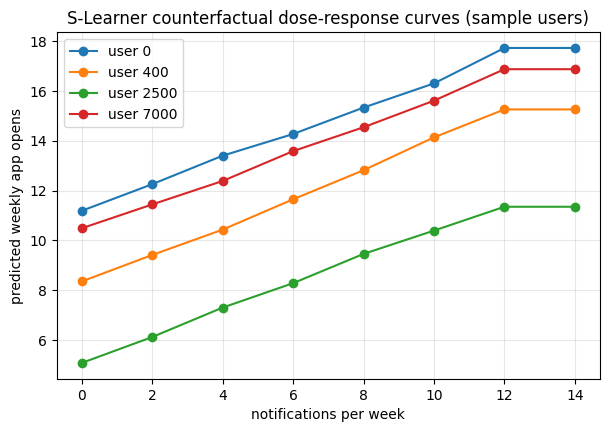

In [14]:
# Plot the estimated dose-response curve for a few illustrative users
sample_users = n_test.reset_index().rename(columns={"index": "user_id"}).iloc[[0, 400, 2500, 7000]]["user_id"].values

fig, ax = plt.subplots()
for uid in sample_users:
    curve = test_cf.query("user_id == @uid").sort_values("notifs_per_week")
    ax.plot(curve["notifs_per_week"], curve["opens_hat"], marker="o", label=f"user {uid}")
ax.set_xlabel("notifications per week")
ax.set_ylabel("predicted weekly app opens")
ax.set_title("S-Learner counterfactual dose-response curves (sample users)")
ax.legend()
plt.show()


Notice the curves have **different shapes** — some rise close to linearly
across the whole range, others flatten (or even turn down) after a few
notifications a week. That heterogeneity is exactly what we want to
capture as a single CATE-like number per user via the slope trick below.


In [15]:
@curry
def linear_effect(df, y, t):
    return np.cov(df[y], df[t])[0, 1] / np.var(df[t])


cate_slope = (
    test_cf
    .groupby("user_id")
    .apply(linear_effect(y="opens_hat", t="notifs_per_week"), include_groups=False)
    .rename("cate")
)

s_learner_pred = n_test.reset_index().rename(columns={"index": "user_id"}).set_index("user_id").join(cate_slope)
s_learner_pred.head()


,baseline_engagement,tenure_months,days_since_last_login,notifs_per_week,weekly_app_opens,true_sensitivity,cate
user_id,,,,,,,
0,11.109632,4.740976,15.863079,13.206188,14.592053,0.525825,0.564324
1,6.562949,2.377263,17.365489,9.646067,13.921995,0.544837,0.580602
2,4.346636,20.057248,3.884254,5.465075,7.199805,0.516632,0.580310
3,16.135130,5.168800,17.432018,13.778804,23.573540,0.384549,0.328666
4,1.288730,4.309586,1.861032,8.432577,7.369900,0.437397,0.375941


S-Learner PEHE (sensitivity/slope vs true marginal sensitivity): 0.041121344631360746


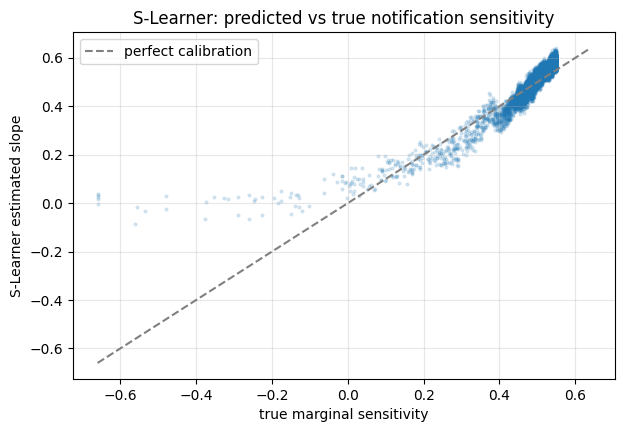

In [16]:
print("S-Learner PEHE (sensitivity/slope vs true marginal sensitivity):",
      pehe(s_learner_pred["true_sensitivity"], s_learner_pred["cate"]))

fig, ax = plt.subplots()
ax.scatter(s_learner_pred["true_sensitivity"], s_learner_pred["cate"], s=4, alpha=0.15)
lims = [s_learner_pred[["true_sensitivity", "cate"]].min().min(),
        s_learner_pred[["true_sensitivity", "cate"]].max().max()]
ax.plot(lims, lims, "--", color="gray", label="perfect calibration")
ax.set_xlabel("true marginal sensitivity")
ax.set_ylabel("S-Learner estimated slope")
ax.set_title("S-Learner: predicted vs true notification sensitivity")
ax.legend()
plt.show()


## 7. R-Learner / Double-ML — orthogonalized CATE for the continuous dose

For continuous treatment, the R-Learner is often the more natural fit: no
grid or counterfactual expansion needed, and it directly targets the
**marginal effect of frequency**, which is exactly the quantity we need to
decide "one more notification: worth it or not?" for each user.

$$\tilde T = T - \hat\mu_t(X), \qquad \tilde Y = Y - \hat\mu_y(X), \qquad
Y^* = \tilde Y / \tilde T \ \text{(weighted by } \tilde T^2\text{)}$$


In [17]:
np.random.seed(123)

debias_m = LGBMRegressor(verbosity=-1)   # predicts notification frequency from X
denoise_m = LGBMRegressor(verbosity=-1)  # predicts opens from X

t_res = n_train[Tn] - cross_val_predict(debias_m, n_train[Xn], n_train[Tn], cv=5)
y_res = n_train[yn] - cross_val_predict(denoise_m, n_train[Xn], n_train[yn], cv=5)

print("Naive OLS slope (confounded data, ignores targeting):",
      sm.OLS(n_train[yn], sm.add_constant(n_train[Tn])).fit().params.iloc[1])
print("Double-ML orthogonalized ATE (avg. marginal effect):",
      sm.OLS(y_res, t_res).fit().params.iloc[0])
print("True average marginal sensitivity:",
      notif_sensitivity(pd.concat([Xn_obs, Xn_rnd])).mean())


Naive OLS slope (confounded data, ignores targeting): -0.45411345188112806
Double-ML orthogonalized ATE (avg. marginal effect): 0.5107716935043416
True average marginal sensitivity: 0.502702677595951


The naive slope is contaminated by the win-back targeting policy (it can
even come out with the wrong sign, since more nudges were sent precisely to
*less* engaged users). The Double-ML orthogonalized estimate lands close to
the true average marginal sensitivity.


R-Learner PEHE: 0.03243344607793529


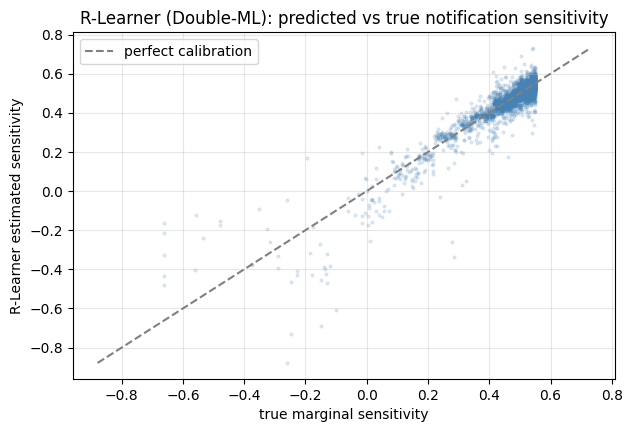

In [18]:
np.random.seed(123)
y_star = y_res / t_res
w = t_res ** 2

r_learner = LGBMRegressor(verbosity=-1)
r_learner.fit(n_train[Xn], y_star, sample_weight=w)

r_learner_pred = n_test.assign(cate=r_learner.predict(n_test[Xn]))

print("R-Learner PEHE:", pehe(r_learner_pred["true_sensitivity"], r_learner_pred["cate"]))

fig, ax = plt.subplots()
ax.scatter(r_learner_pred["true_sensitivity"], r_learner_pred["cate"], s=4, alpha=0.15, color="steelblue")
lims = [r_learner_pred[["true_sensitivity", "cate"]].min().min(),
        r_learner_pred[["true_sensitivity", "cate"]].max().max()]
ax.plot(lims, lims, "--", color="gray", label="perfect calibration")
ax.set_xlabel("true marginal sensitivity")
ax.set_ylabel("R-Learner estimated sensitivity")
ax.set_title("R-Learner (Double-ML): predicted vs true notification sensitivity")
ax.legend()
plt.show()


In [19]:
pd.DataFrame({
    "S-Learner": dict(PEHE=pehe(s_learner_pred["true_sensitivity"], s_learner_pred["cate"])),
    "R-Learner": dict(PEHE=pehe(r_learner_pred["true_sensitivity"], r_learner_pred["cate"])),
}).T


,PEHE
S-Learner,0.041121
R-Learner,0.032433


On this dataset the R-Learner should come out **noticeably more accurate**
than the S-Learner — a nice illustration of the book's point that the
S-Learner tends to under-use a treatment signal that's weak relative to the
other covariates (here, `baseline_engagement` dominates the outcome, and a
regularized single model can under-fit the frequency effect), whereas the
R-Learner's orthogonalization protects the treatment signal explicitly.


# Part 3 — Turning both into operating decisions

## 8. Algorithm rollout: staged plan under an infra-capacity constraint

Suppose infra can only support serving the new algorithm to **30% of
users** in the next rollout phase (compute cost, not user preference, is
the constraint). Using the X-Learner's CATE ranking, target the top 30% by
predicted lift instead of rolling out arbitrarily (e.g., to everyone in a
region, or randomly).


In [20]:
x_pct, gains = cumulative_gain_curve(x_learner_pred, "cate", y, T)
gain_at_30 = np.interp(30, x_pct, gains)
random_gain_at_30 = gains[-1] * 0.30

print(f"Estimated incremental weekly watch-hours from targeting the top 30% by predicted lift: {gain_at_30:,.3f}")
print(f"Estimated incremental weekly watch-hours from rolling out to a random 30%:              {random_gain_at_30:,.3f}")
print(f"Uplift from targeting vs. random rollout: {100*(gain_at_30/random_gain_at_30 - 1):.1f}%")


Estimated incremental weekly watch-hours from targeting the top 30% by predicted lift: 1.536
Estimated incremental weekly watch-hours from rolling out to a random 30%:              1.163
Uplift from targeting vs. random rollout: 32.1%


## 9. Notification policy: per-user frequency under a fatigue budget

Using the R-Learner's per-user sensitivity estimates, a simple policy: send
**more notifications to users with high estimated sensitivity**, and **cut
back (or stop) notifications for users with sensitivity near or below
zero** (fatigue risk), subject to an average frequency budget the team has
agreed with lifecycle marketing (e.g., average ≤ 5 notifications/week
across the user base, to control unsubscribe risk).


In [21]:
budget = 5.0  # average notifications/week across the base

# Simple proportional-to-sensitivity allocation, clipped to [0, 14], rescaled to hit the budget
raw = r_learner_pred["cate"].clip(lower=0.05)  # floor to avoid divide-by-zero / all-zero allocation
alloc = raw / raw.mean() * budget
alloc = alloc.clip(0, 14)

policy = r_learner_pred.assign(recommended_freq=alloc)

print("Average recommended frequency (should be close to budget):", policy["recommended_freq"].mean())
print("\nRecommended frequency by true-sensitivity tercile (sanity check — should increase with sensitivity):")
policy["sensitivity_tercile"] = pd.qcut(policy["true_sensitivity"], 3, labels=["low", "mid", "high"])
policy.groupby("sensitivity_tercile")["recommended_freq"].mean()


Average recommended frequency (should be close to budget): 5.0

Recommended frequency by true-sensitivity tercile (sanity check — should increase with sensitivity):


sensitivity_tercile
low     4.370387
mid     5.204161
high    5.425641
Name: recommended_freq, dtype: float64

As a sanity check, the policy should allocate **more notifications to the
high-sensitivity tercile** and fewer to the low-sensitivity one — the
opposite pattern from the original win-back policy, which sent *more*
notifications to lapsed (frequently low-sensitivity) users. This is the
practical output of the whole exercise: a **defensible, effect-driven**
targeting rule instead of a rule based on raw engagement level.


## 10. Key takeaways / decision guide

| Decision | Treatment type | Learner(s) used | Why |
|---|---|---|---|
| New recommender rollout | Binary (has new algo / doesn't) | T-Learner, **X-Learner** | Canary releases start highly imbalanced (few treated); X-Learner corrects the resulting regularization bias |
| Notification frequency | Continuous (0–14/week) | S-Learner, **R-Learner (Double-ML)** | Need a full dose-response / marginal-effect estimate, not just a treated-vs-control difference; R-Learner protects a treatment signal that's weak relative to other covariates |

**Practical lessons that generalize beyond this notebook:**

- **Staged rollouts are inherently imbalanced.** Any canary release, feature
  flag, or opt-in beta is, by construction, the "few treated / many
  control" scenario the book warns about — which makes the **X-Learner** a
  better default than the T-Learner for early-stage rollout decisions, even
  if you switch back to a T-Learner once the rollout is closer to 50/50.
- **Marketing/lifecycle actions are usually confounded by design**, not by
  accident — win-back policies, retargeting, and "send more to at-risk
  users" logic are exactly the kind of targeting that breaks naive
  before/after or treated/untreated comparisons. Orthogonalization
  (R-Learner/Double-ML) is built for this.
- **Continuous treatments need a different toolkit.** Binary metalearners
  answer "did it help?"; continuous ones need to answer "how much of it,
  for whom?" — that's a full dose-response question, and the
  R-Learner gives you the marginal-effect number that a real policy (like
  the fatigue-budget allocation above) can act on directly.
- **Always hold out a randomized slice for evaluation.** Every conclusion in
  this notebook — which learner is better, what the true rollout lift is,
  what the notification sensitivity actually looks like — depended on
  having `data_ab` / `notif_rnd` to check against. Without it, you're
  trusting a causal model's own training data to grade its own homework.
